# hydromend quickstart — GESLA + GTSM, end to end

This notebook shows the whole `hydromend` workflow on **one real tide gauge**:

1. load the gauge and its **nearest GTSM-ERA5 point** straight from the raw data,
2. **fit** a bilinear (Volterra) lag operator,
3. look at the **learned kernel**,
4. **evaluate** the correction on a held-out period, and
5. **save / reload** the operator as an `OperatorLibrary` — the format a released
   weight dataset (e.g. the ERA5-GTSM library on Zenodo) ships in.

Only two paths need editing for your machine: `GESLA_DIR` and `GTSM_GLOB`.

In [1]:
import os
# Keep BLAS single-threaded so a laptop stays responsive during the fit.
for v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(v, "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import hydromend as hm
from hydromend import gtsm
from hydromend.datasets import load_pair

# --- point these at your local data -----------------------------------------
GESLA_DIR = "/Users/scro4480/Desktop/GESLA4.1_ALL"
GTSM_GLOB = "/Users/scro4480/Desktop/data/GTSM_ERA5_E/water_level_*/*_v3.nc"

SITE_FILE = "brest-3-fra-refmar"     # a macro-tidal gauge (range ~6 m)
YEARS = (2012, 2021)                  # a recent window keeps the demo fast
print("hydromend", hm.__version__)

hydromend 0.1.0


## 1. Load the gauge and its nearest GTSM point

`load_pair` reads the GESLA-4.1 record, finds the closest GTSM station, streams
just that station out of the monthly NetCDFs, and returns one hourly-aligned
frame with `observations` and `model` columns.

In [2]:
df, info = load_pair(os.path.join(GESLA_DIR, SITE_FILE), GTSM_GLOB,
                     start=YEARS[0], end=YEARS[1])
print(f"site: {info['site']}  ({info['lat']:.3f}, {info['lon']:.3f})")
print(f"nearest GTSM station #{info['station_index']} at {info['gtsm_dist_km']:.2f} km")
print(f"{len(df):,} aligned hourly steps, {df.index[0].date()} -> {df.index[-1].date()}")
df.head()

site: Brest  (48.383, -4.495)
nearest GTSM station #39272 at 0.85 km
77,918 aligned hourly steps, 2012-01-01 -> 2021-01-01


,observations,model
2012-01-01 00:00:00,4.007,-0.145
2012-01-01 01:00:00,3.422,-0.808
2012-01-01 02:00:00,2.921,-1.391
2012-01-01 03:00:00,2.710,-1.685
2012-01-01 04:00:00,2.975,-1.466


## 2. A first look — raw GTSM vs the gauge

The gauge and GTSM live on **different vertical datums**, so we shift GTSM onto the
gauge datum (subtract the mean offset) before comparing — the operator learns this
offset as its intercept. Even datum-matched, the reanalysis mis-times and
under-resolves the large astronomical tide here: exactly what a lag operator fixes.

datum-matched raw GTSM MAE vs gauge: 0.164 m


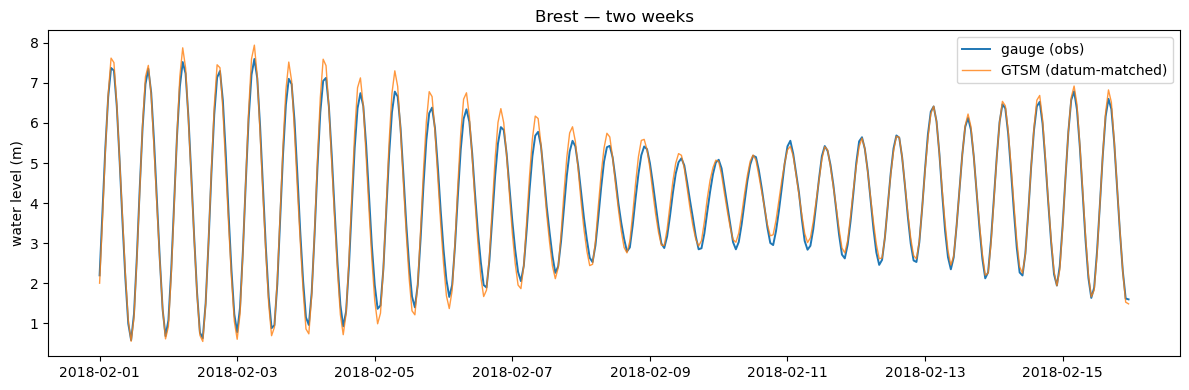

In [3]:
model_dm = df["model"] - (df["model"].mean() - df["observations"].mean())   # onto gauge datum

win = slice("2018-02-01", "2018-02-15")
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df[win].index, df[win]["observations"], label="gauge (obs)", lw=1.4)
ax.plot(model_dm[win].index, model_dm[win], label="GTSM (datum-matched)", lw=1.0, alpha=0.8)
ax.set_ylabel("water level (m)"); ax.legend(); ax.set_title(f"{info['site']} — two weeks")
fig.tight_layout()

raw_mae = (df["observations"] - model_dm).abs().mean()
print(f"datum-matched raw GTSM MAE vs gauge: {raw_mae:.3f} m")

## 3. Fit a bilinear lag operator

We use a 24 h memory (lags 0–24 h) with the full second-order Volterra feature
set (`include_squares=True` keeps the τ₁=τ₂ overtide diagonal), and an
ARD-regularised fit. We hold out the last third of the record for honest
evaluation.

In [4]:
RECIPE = dict(predictor_columns=("model",), lags_hours=list(range(1, 25)),
              feature_set="bilinear", include_current=True, include_squares=True)

X = hm.build_feature_set(df, **RECIPE)
d = pd.concat([X, df["observations"]], axis=1).dropna()
split = int(len(d) * 0.67)
Xtr, ytr = d.iloc[:split][X.columns], d.iloc[:split]["observations"]
Xte, yte = d.iloc[split:][X.columns], d.iloc[split:]["observations"]

reg = hm.make_regressor().fit(Xtr, ytr)     # default = variational-Bayes ARD
print(f"fitted {len(reg.coef_)} weights on {len(Xtr):,} samples "
      f"(train {Xtr.index[0].date()} -> {Xtr.index[-1].date()})")

fitted 350 weights on 52,188 samples (train 2012-01-02 -> 2018-01-10)


## 4. What did it learn?

The **linear kernel** $w(\tau)$ shows how the operator blends recent GTSM values;
the **bilinear surface** $w(\tau_1,\tau_2)$ shows the tide–tide / tide–surge
interactions — the diagonal carries the overtide (self-product) terms.

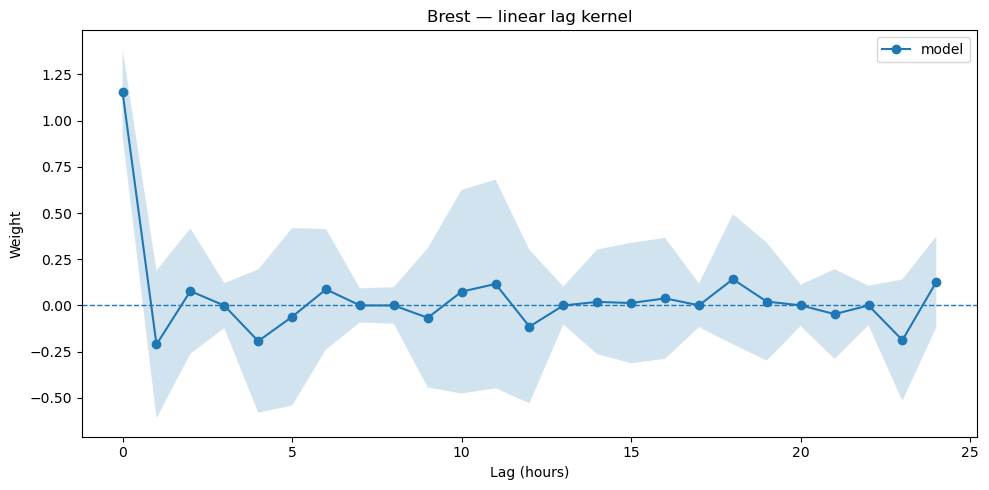

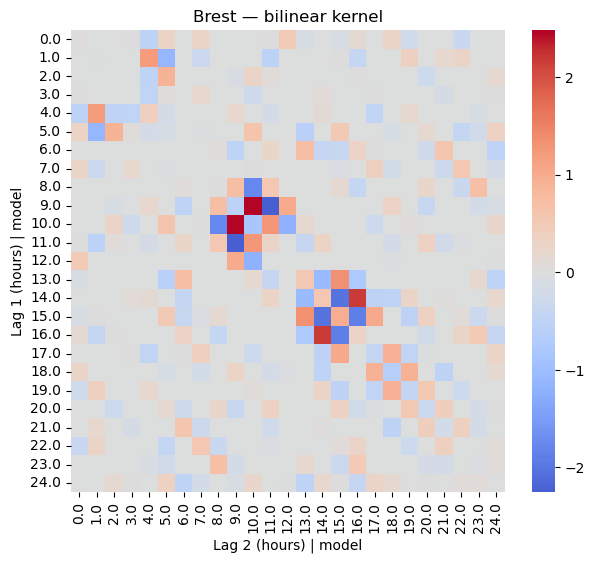

In [5]:
w = hm.extract_linear_lag_weights(reg, X.columns)
hm.plot_lag_weight_kernel(w, title=f"{info['site']} — linear lag kernel")
plt.show()

surf = hm.extract_bilinear_lag_surface(reg, X.columns)
hm.plot_bilinear_kernel_surface(surf, title=f"{info['site']} — bilinear kernel")
plt.show()

## 5. Evaluate on the held-out period

held-out MAE:  raw 0.164 m  ->  operator 0.100 m (+39%)


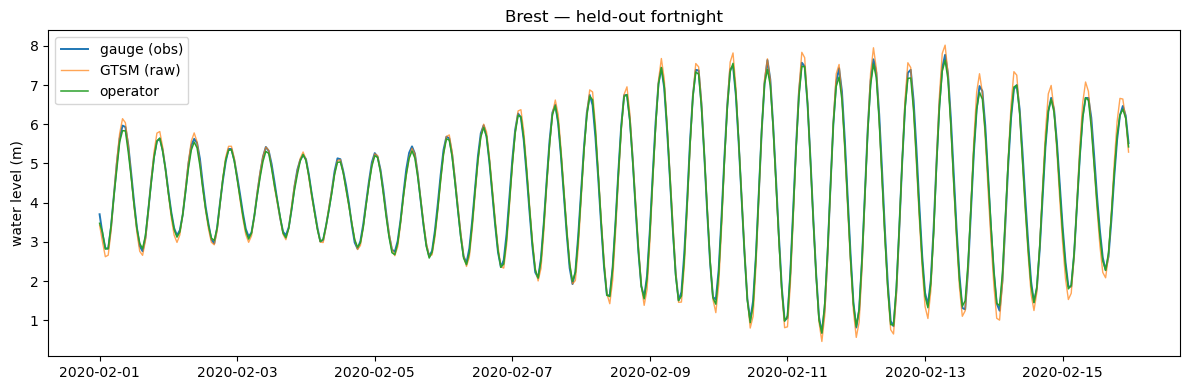

In [6]:
pred_te = pd.Series(reg.predict(Xte), index=Xte.index)
# datum-match the raw baseline the same way (remove mean offset) for a fair MAE
base_te = df["model"].reindex(Xte.index)
base_te = base_te - (base_te.mean() - yte.mean())

op_mae = (yte - pred_te).abs().mean()
raw_mae_te = (yte - base_te).abs().mean()
print(f"held-out MAE:  raw {raw_mae_te:.3f} m  ->  operator {op_mae:.3f} m "
      f"({100*(raw_mae_te-op_mae)/raw_mae_te:+.0f}%)")

win = slice("2020-02-01", "2020-02-15")
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(yte[win].index, yte[win], label="gauge (obs)", lw=1.4)
ax.plot(base_te[win].index, base_te[win], label="GTSM (raw)", lw=1.0, alpha=0.7)
ax.plot(pred_te[win].index, pred_te[win], label="operator", lw=1.1)
ax.set_ylabel("water level (m)"); ax.legend(); ax.set_title(f"{info['site']} — held-out fortnight")
fig.tight_layout()

## 6. Save, ship, reload — the release format

Wrap the fitted regressor in an `Operator`, collect operators into an
`OperatorLibrary`, and round-trip it through a single Parquet file. This is
exactly how a released weight dataset is distributed and consumed.

In [7]:
op = hm.Operator.from_regressor(
    reg, feature_names=list(X.columns), **RECIPE,
    metadata={"site": info["site"], "lat": info["lat"], "lon": info["lon"],
              "tidal_range_m": 6.24, "gtsm_station_index": info["station_index"]},
)
lib = hm.OperatorLibrary.from_operators([op])
lib.to_parquet("my_operators.parquet")

lib2 = hm.OperatorLibrary.from_parquet("my_operators.parquet")
op2 = lib2.nearest(info["lat"], info["lon"])        # or lib2.get(info["site"])
print(op2, "|", f"{op2.metadata['query_dist_km']:.2f} km from query")

# apply the reloaded operator to any GTSM series for this point
reloaded_pred = op2.predict(df[["model"]]).reindex(Xte.index)
print("reload reproduces the fit:", np.allclose(reloaded_pred, pred_te, atol=1e-9))

<Operator Brest bilinear n_lags=24 n_feat=350 TR=6.2m> | 0.00 km from query


reload reproduces the fit: True


## 7. Using the released ERA5-GTSM library

Once you have the published weights file, applying it anywhere is three lines —
no fitting required. (The cell is guarded so the notebook still runs without it.)

In [8]:
LIB_PATH = "era5gtsm_operators.parquet"   # download the released weights here
if os.path.exists(LIB_PATH):
    era5 = hm.OperatorLibrary.from_parquet(LIB_PATH)   # add primary_only=True to dedupe
    print(f"released library: {len(era5)} operators")
    op = era5.nearest(info["lat"], info["lon"], max_km=25)
    m = op.metadata
    print(f"nearest: {m.get('site')}  TR={m.get('tidal_range_m'):.1f} m  "
          f"in-sample MAE {m.get('mae_raw'):.3f} -> {m.get('mae_op'):.3f} m")
    corrected = op.predict(df[["model"]])
    print(f"applied to {corrected.notna().sum():,} steps")
else:
    print("Released library not found — download it (e.g. from Zenodo) to LIB_PATH.")

Released library not found — download it (e.g. from Zenodo) to LIB_PATH.
